In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as pyt

In [2]:
data = {
    "City": ["Tokyo", "New York", "London", "Paris"],
    "Latitude": [35.6895, 40.7128, 51.5074, 48.8566],
    "Longitude": [139.6917, -74.0060, -0.1278, 2.3522],
}

df = pd.DataFrame(data)

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))
gdf

,City,Latitude,Longitude,geometry
0,Tokyo,35.6895,139.6917,POINT (139.6917 35.6895)
1,New York,40.7128,-74.0060,POINT (-74.006 40.7128)
2,London,51.5074,-0.1278,POINT (-0.1278 51.5074)
3,Paris,48.8566,2.3522,POINT (2.3522 48.8566)


In [3]:
url = "https://github.com/opengeos/datasets/releases/download/vector/nybb.geojson"
gdf = gpd.read_file(url)
gdf.head()


,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [4]:
output_file = "nyc_buroughs.gpkg"
gdf.to_file(output_file)

In [5]:
gdf_4326 = gdf.to_crs(epsg=4326)
print(f"Reprojected CRS: {gdf_4326.crs}")
gdf_4326.head()

Reprojected CRS: EPSG:4326


,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((-73.83668 40.59495, -73.83678 ..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((-73.86706 40.58209, -73.86769 ..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."


In [6]:
gdf = gdf.to_crs("EPSG:3857")
gdf = gdf.set_index("BoroName")

In [7]:
gdf["area"] = gdf.area
gdf["area_km2"] = gdf['area'] / 1_000_000
gdf[["area", "area_km2"]].sort_values("area_km2", ascending=False)
gdf["boundary"] = gdf.boundary
gdf["centroid"] = gdf.centroid
gdf[["boundary", "centroid"]].head()

,boundary,centroid
BoroName,,
Staten Island,"MULTILINESTRING ((-8243264.851 4948597.836, -8...",POINT (-8254713.541 4950718.061)
Queens,"MULTILINESTRING ((-8219461.925 4952778.732, -8...",POINT (-8217436.751 4969318.726)
Brooklyn,"MULTILINESTRING ((-8222843.672 4950893.793, -8...",POINT (-8231817.467 4960085.273)
Manhattan,"MULTILINESTRING ((-8238858.864 4965915.024, -8...",POINT (-8233984.803 4979551.765)
Bronx,"MULTILINESTRING ((-8226155.13 4982269.949, -82...",POINT (-8222783.631 4990631.242)


In [8]:
manhattan_centroid = gdf.loc["Manhattan", "centroid"]
gdf["distance_to_manhattan"] = gdf["centroid"].distance(manhattan_centroid)
gdf["distance_to_manhattan_km"] = gdf['distance_to_manhattan'] / 1000
gdf[["distance_to_manhattan_km"]].sort_values("distance_to_manhattan_km")
mean_distance = gdf["distance_to_manhattan_km"].mean()
max_distance = gdf["distance_to_manhattan_km"].max()
total_area = gdf["area_km2"].sum()

print(f"Mean distance to Manhattan: {mean_distance:.2f} km")
print(f"Maximum distance to Manhattan: {max_distance:.2f} km")
print(f"Total NYC area: {total_area:.2f} km²")

Mean distance to Manhattan: 18.06 km
Maximum distance to Manhattan: 35.51 km
Total NYC area: 1363.75 km²


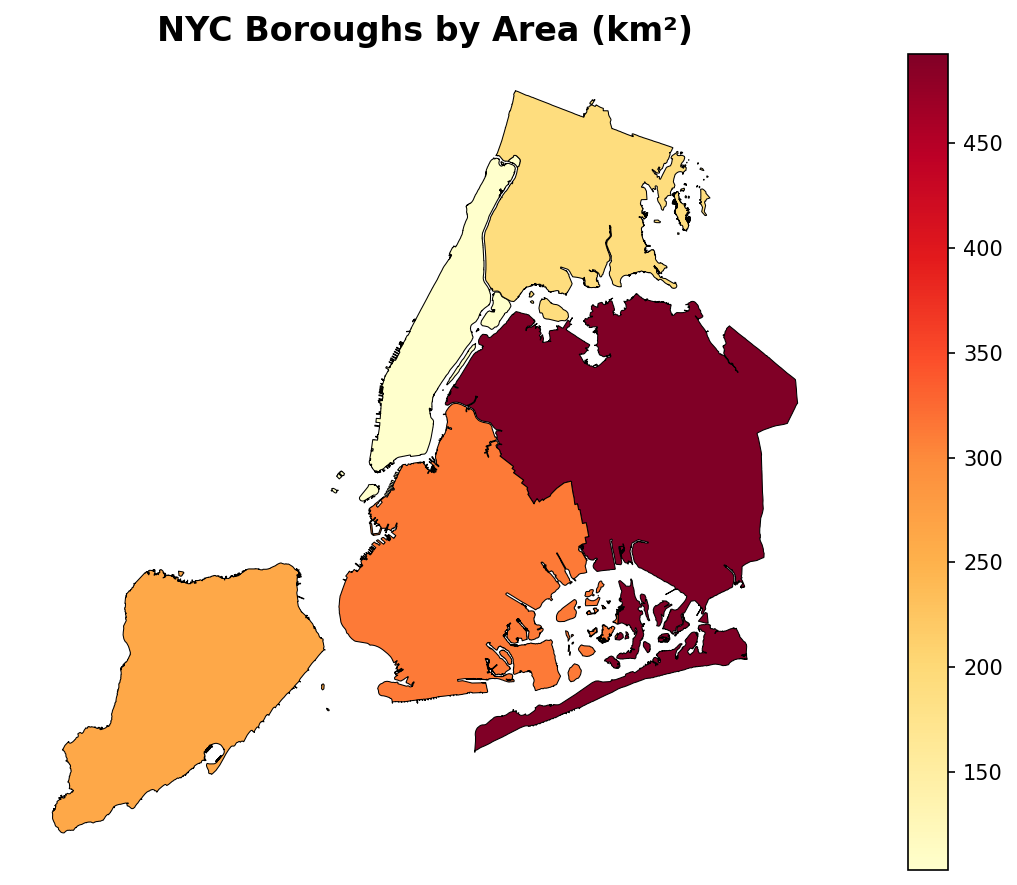

In [9]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150

fig, ax = plt.subplots(figsize=(10, 6))

gdf.plot(
    column="area_km2",
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.5
)

plt.title("NYC Boroughs by Area (km²)", fontsize=16, fontweight="bold")
plt.axis("off") # Remove coordinate axes for cleaner appearance
plt.tight_layout()
plt.show()

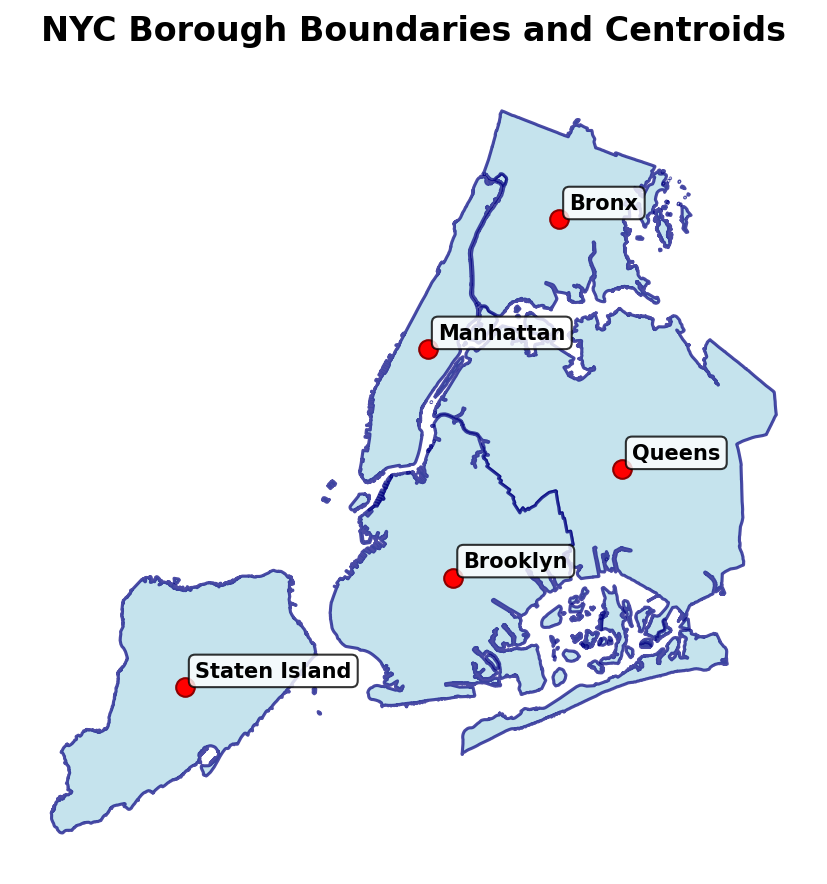

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
gdf["geometry"].plot(
    ax = ax,
    color = "lightblue",
    edgecolor = "navy",
    linewidth = 1.5,
    alpha = 0.7
)

gdf["centroid"].plot(
    ax = ax,
    color = "red",
    markersize = 80,
    edgecolor = "darkred",
    linewidth = 1
)

for idx, row in gdf.iterrows():
    x = row.centroid.x
    y = row.centroid.y
    ax.annotate(
        idx,
        (x, y),
        xytext=(5, 5),
        textcoords = "offset points",
        fontsize = 10,
        fontweight = "bold",
        bbox = dict(boxstyle = "round,pad=0.3", facecolor="white", alpha = 0.8)
    )

plt.title("NYC Borough Boundaries and Centroids", fontsize=16, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
m = gdf.explore(
    column = "area_km2",
    cmap = "YlOrRd",
    tooltip = ["area_km2", "distance_to_manhattan_km"],
    popup = True,
    legend = True
)
m

In [12]:
buffer_distance = 3000
gdf["buffered"] = gdf.buffer(buffer_distance)
print(f"Created {buffer_distance/1000} km buffer zones around each borough")

Created 3.0 km buffer zones around each borough


<positron-console-cell-13>:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
<positron-console-cell-13>:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


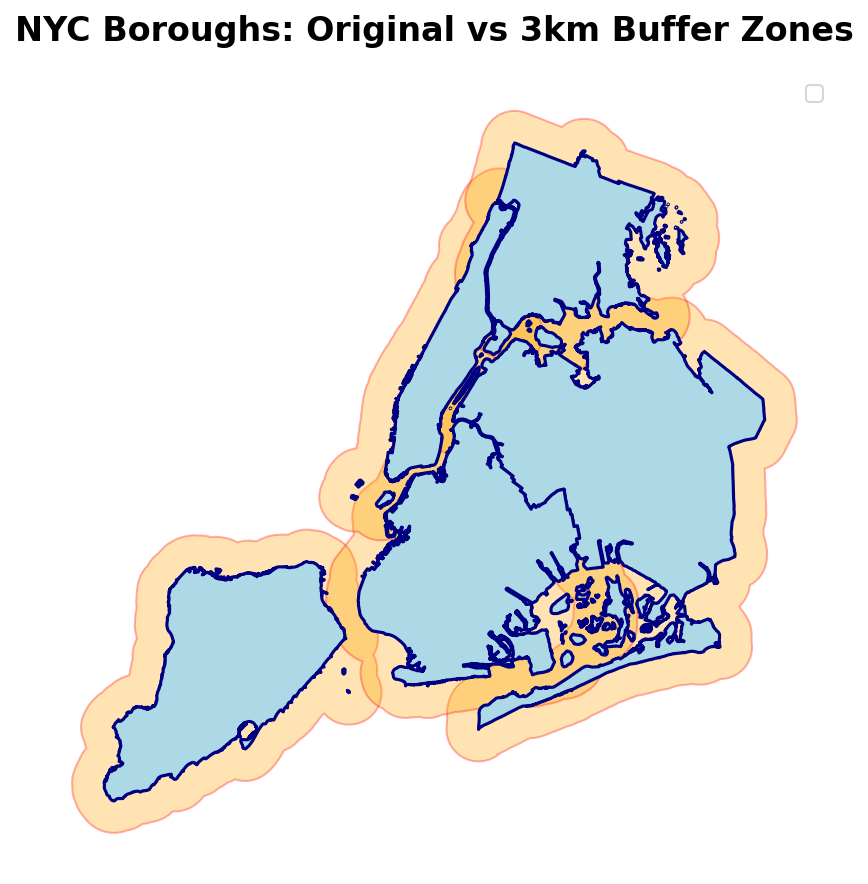

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

gdf["buffered"].plot(
    ax=ax,
    alpha = 0.3,
    color = "orange",
    edgecolor = "red",
    linewidth = 1,
    label = "3km Buffer Zone"
)

gdf["geometry"].plot(
    ax = ax,
    color = "lightblue",
    edgecolor = "navy",
    linewidth = 1.5,
    label = "Original Boundaries"
)

plt.title("NYC Boroughs: Original vs 3km Buffer Zones", fontsize=16,
fontweight="bold")
plt.legend(loc="upper right")
plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
gdf["convex_hull"] = gdf.convex_hull
gdf["convex_hull_area"] = gdf["convex_hull"].area /1_000_000
gdf["area_ratio"] = gdf["convex_hull_area"] / gdf["area_km2"]

print("Convex Hull Analysis:")
print(gdf[["area_km2", "convex_hull_area", "area_ratio"]].round(2))


Convex Hull Analysis:
               area_km2  convex_hull_area  area_ratio
BoroName                                             
Staten Island    261.80            332.54        1.27
Queens           492.83            845.79        1.72
Brooklyn         312.97            405.32        1.30
Manhattan        103.22            178.16        1.73
Bronx            192.93            269.55        1.40


<positron-console-cell-15>:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
<positron-console-cell-15>:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


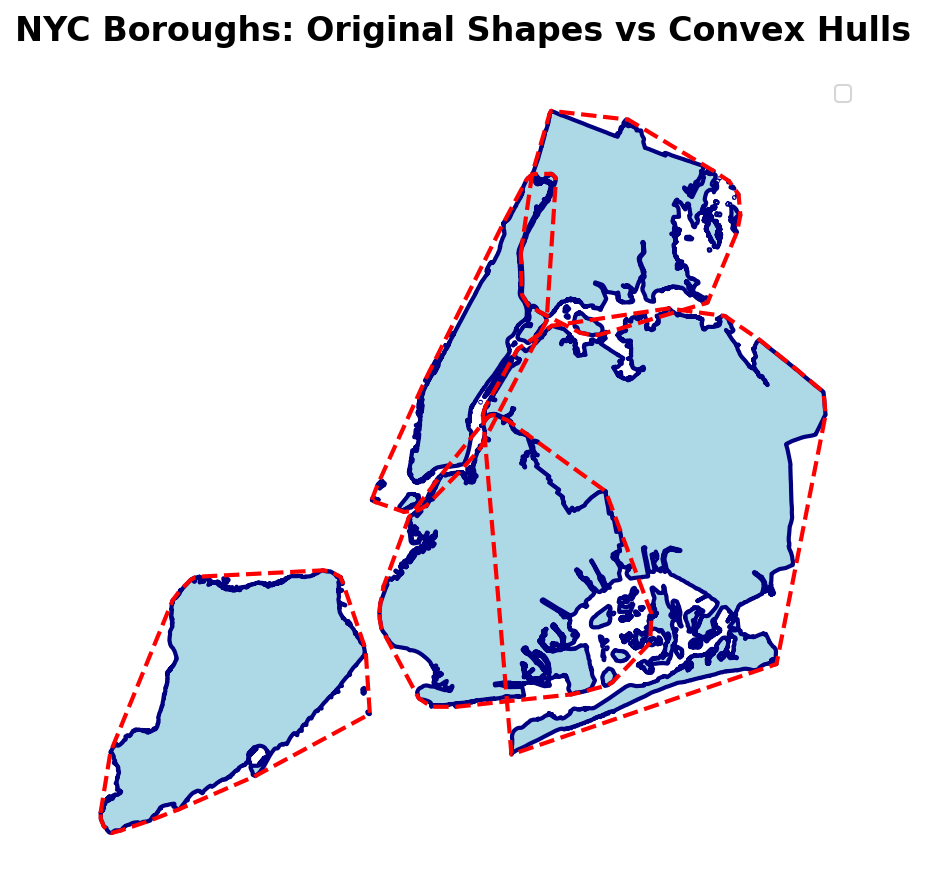

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
gdf["geometry"].plot(
    ax=ax,
    color="lightblue",
    edgecolor="navy",
    linewidth=2,
    label="Original Shape"
)

gdf["convex_hull"].plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    linestyle="--",
    label="Convex Hull"
)

plt.title(
"NYC Boroughs: Original Shapes vs Convex Hulls", fontsize=16,
fontweight="bold"
)
plt.legend(loc="upper right")
plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
manhattan_geom = gdf.loc["Manhattan", "geometry"]
gdf["intersects_manhattan"] = gdf["buffered"].intersects(manhattan_geom)
gdf["touches_manhattan"] = gdf["geometry"].touches(manhattan_geom)

intersection_results = gdf[["intersects_manhattan", "touches_manhattan"]]
intersection_results

,intersects_manhattan,touches_manhattan
BoroName,,
Staten Island,False,False
Queens,True,True
Brooklyn,True,True
Manhattan,True,False
Bronx,True,True


In [17]:
gdf["centroid_within_burough"] = gdf["centroid"].within(gdf["geometry"])

anomalies = gdf[~gdf["centroid_within_burough"]]

if len(anomalies) > 0:
    print("Warning: Some centroids fall outside their borough boundaries")
    print(anomalies.index.tolist())
else:
    print("✓ All centroids correctly fall within their borough boundaries")

✓ All centroids correctly fall within their borough boundaries


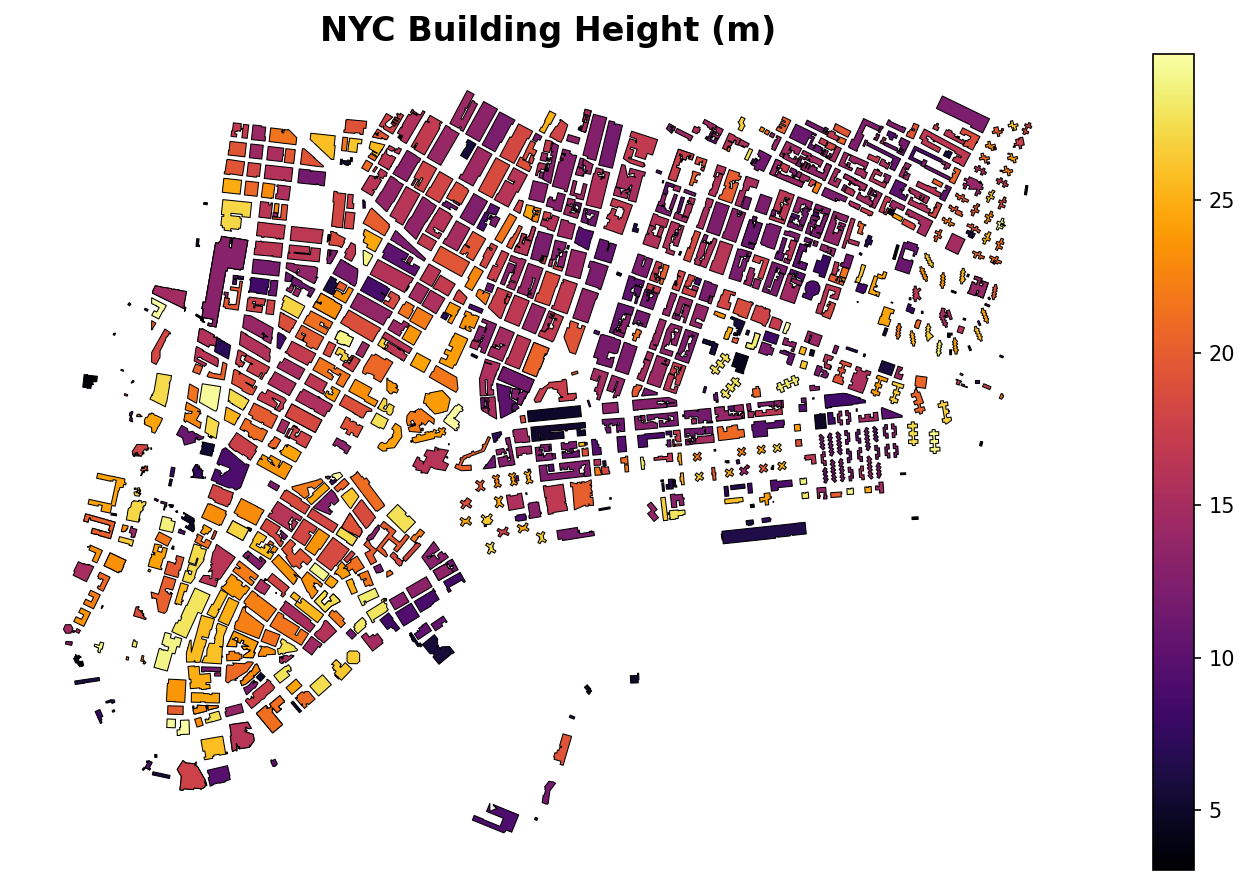

In [18]:
url = " https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson"
gdf = gpd.read_file(url)
gdf.head()

fig, ax = plt.subplots(figsize=(10, 6))
gdf.plot(
column="height_MS",
ax=ax,
legend=True,
cmap="inferno",
edgecolor="black",
linewidth=0.5
)
plt.title("NYC Building Height (m)", fontsize=16, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()



In [19]:
m = gdf.explore(
    column="height_MS",
    cmap = "inferno",
    tooltip="height_MS",
    popup=True,
    legend=True
)
m

In [20]:
avg_build_ht = gdf["height_MS"].mean()
abv_mean = gdf[gdf["height_MS"] > avg_build_ht]
abv_mean.to_file("~/projects/Git_projects/python/spatial/itgp/NYC_filter", driver="GeoJSON")

In [30]:

url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
df = gpd.read_file(url)
df["latitude"] = df["latitude"].astype('float')
df["longitude"] = df["longitude"].astype('float')
filter_df = df[(60 > df["latitude"]) & (df["latitude"] > -40)]
filter_gdf = gpd.GeoDataFrame(
    filter_df, geometry = gpd.points_from_xy(filter_df.longitude, filter_df.latitude, crs="EPSG:4326")
)
filter_gdf = filter_gdf.to_crs("EPSG:3857")
filter_gdf = filter_gdf.set_index("name")
paris_geom = filter_gdf.loc["Paris", "geometry"]
filter_gdf["distance_to_paris"] = filter_gdf["geometry"].distance(paris_geom)
filter_gdf["distance_to_paris_km"] = filter_gdf["distance_to_paris"]

m = filter_gdf.explore(
    column="distance_to_paris",
    cmap = "inferno",
    tooltip="id",
    popup=True,
    legend=True
)
m
